# 🧪 A/B Testing: Random Forest vs CNN untuk Deteksi Stunting
## Proyek SIDIAS — Perbandingan Model Tabular vs Computer Vision

---
### 📋 Overview A/B Testing

| Komponen | Detail |
|---|---|
| **Model A** | Random Forest (Data Tabular / Antropometri) |
| **Model B** | CNN / Computer Vision (Data Gambar Balita) |
| **Tujuan** | Menentukan model mana yang lebih andal untuk produksi |
| **Metrik Utama** | Accuracy, F1-Score, ROC-AUC, Precision, Recall |
| **Metode Statistik** | McNemar's Test + Bootstrap Confidence Interval |

> **Catatan Penting:** Model A (RF) menggunakan data tabular → **Klasifikasi Biner** (Stunting / Tidak).
> Model B (CNN) menggunakan data gambar → **Klasifikasi 3 Kelas** (Healthy / MalNutrisi / Stunting).
> Pada tahap A/B Testing ini, output CNN akan dipetakan ke biner untuk perbandingan yang adil.

## 📦 Cell 1: Import Library & Setup

In [43]:
# ===================================================
# CELL 1: IMPORT LIBRARY & KONFIGURASI
# ===================================================
import os
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from scipy import stats
from scipy.stats import bootstrap

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)

# ── Styling ──────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'A': '#2196F3', 'B': '#FF5722', 'green': '#4CAF50', 'gray': '#9E9E9E'}
np.random.seed(42)

# — Path Konfigurasi (Disesuaikan dengan Google Colab) —
BASE_PATH = 'SIDIAS-/data_science/'

PATH_RF_MODEL   = BASE_PATH + 'models/random_forest_stunting_model.pkl'
PATH_CNN_MODEL  = BASE_PATH + 'models/cnn_stunting_vision_model.h5'
PATH_TEST_TAB   = BASE_PATH + 'data/data_fe/tabular_test_features.csv'
PATH_TRAIN_TAB  = BASE_PATH + 'data/data_fe/tabular_train_features.csv'
PATH_IMAGE_TEST = BASE_PATH + 'data/processed/gambar/test/'

FEATURES = ['usia_bulan', 'jenis_kelamin_encoded', 'tinggi_badan',
            'berat_badan', 'imt', 'tinggi_per_usia']
CNN_CLASSES = ['Healthy', 'MalNutrisi', 'Stunting']

# Jalankan print ini untuk memastikan library aman
print('✅ Library berhasil diimport!')

print(f'   NumPy     : {np.__version__}')
print(f'   Pandas    : {pd.__version__}')
print(f'   Sklearn   : Siap')
print(f'   Seaborn   : {sns.__version__}')

✅ Library berhasil diimport!
   NumPy     : 2.0.2
   Pandas    : 2.2.2
   Sklearn   : Siap
   Seaborn   : 0.13.2


## 🤖 Cell 2: Load Model A — Random Forest

In [44]:
# ===================================================
# CELL 2: LOAD MODEL A — RANDOM FOREST
# ===================================================
print('━' * 55)
print('  📦 Loading Model A: Random Forest')
print('━' * 55)

rf_model = joblib.load(PATH_RF_MODEL)

print(f'  ✅ Model berhasil dimuat!')
print(f'  Tipe       : {type(rf_model).__name__}')
print(f'  N Estimator: {rf_model.n_estimators}')
print(f'  Max Depth  : {rf_model.max_depth}')
print(f'  N Features : {rf_model.n_features_in_}')
print(f'  Classes    : {rf_model.classes_}  (0=Tidak Stunting, 1=Stunting)')
print(f'  Random Seed: {rf_model.random_state}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📦 Loading Model A: Random Forest
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅ Model berhasil dimuat!
  Tipe       : RandomForestClassifier
  N Estimator: 100
  Max Depth  : 10
  N Features : 6
  Classes    : [0 1]  (0=Tidak Stunting, 1=Stunting)
  Random Seed: 42


## 🖼️ Cell 3: Load Model B — CNN

In [45]:
# ===================================================
# CELL 3: LOAD MODEL B — CNN
# ===================================================
print('━' * 55)
print('  📦 Loading Model B: CNN (Computer Vision)')
print('━' * 55)

import tensorflow as tf

# Trik khusus untuk mengabaikan parameter renorm dari Keras versi lama
class SafeBatchNormalization(tf.keras.layers.BatchNormalization):
    def __init__(self, *args, **kwargs):
        # Hapus keyword arguments penyebab error jika terbaca dari file .h5
        kwargs.pop('renorm', None)
        kwargs.pop('renorm_clipping', None)
        kwargs.pop('renorm_momentum', None)
        super().__init__(*args, **kwargs)

# Muat model dengan menyuntikkan class kustom di atas
cnn_model = tf.keras.models.load_model(
    PATH_CNN_MODEL,
    custom_objects={'BatchNormalization': SafeBatchNormalization}
)

# Ringkasan arsitektur
total_params = cnn_model.count_params()
print(f'  ✅ Model CNN berhasil dimuat!')
print(f'  Total Parameter : {total_params:,}')
print(f'  Input Shape     : {cnn_model.input_shape}')
print(f'  Output Shape    : {cnn_model.output_shape}  → 3 Kelas')
print(f'  Kelas Output    : {CNN_CLASSES}')
print()
cnn_model.summary()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📦 Loading Model B: CNN (Computer Vision)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


  ✅ Model CNN berhasil dimuat!
  Total Parameter : 102,595
  Input Shape     : (None, 224, 224, 3)
  Output Shape    : (None, 3)  → 3 Kelas
  Kelas Output    : ['Healthy', 'MalNutrisi', 'Stunting']



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (SafeBatchNormalization)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (SafeBatchNormalization)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (SafeBatchNormalization)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,597 (400.77 KB)

 Trainable params: 102,147 (399.01 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2 (12.00 B)

## 📊 Cell 4: Load & Inspect Data Test Tabular

In [46]:
# ===================================================
# CELL 4: LOAD DATA TEST TABULAR
# ===================================================
print('━' * 55)
print('  📂 Loading Data Tabular (Train & Test)')
print('━' * 55)

df_train = pd.read_csv(PATH_TRAIN_TAB)
df_test  = pd.read_csv(PATH_TEST_TAB)

X_test = df_test[FEATURES]
y_test = df_test['target']

print(f'  Train set : {df_train.shape[0]:,} sampel | {df_train.shape[1]} kolom')
print(f'  Test set  : {df_test.shape[0]:,} sampel  | {df_test.shape[1]} kolom')
print()
print('  Distribusi Label — Test Set:')
vc = y_test.value_counts()
print(f'    Tidak Stunting (0) : {vc[0]:,} ({vc[0]/len(y_test)*100:.1f}%)')
print(f'    Stunting (1)       : {vc[1]:,} ({vc[1]/len(y_test)*100:.1f}%)')
print()
print('  Sample data (5 baris pertama):')
display(df_test.head())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📂 Loading Data Tabular (Train & Test)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train set : 32,052 sampel | 7 kolom
  Test set  : 8,014 sampel  | 7 kolom

  Distribusi Label — Test Set:
    Tidak Stunting (0) : 3,240 (40.4%)
    Stunting (1)       : 4,774 (59.6%)

  Sample data (5 baris pertama):


,usia_bulan,jenis_kelamin_encoded,tinggi_badan,berat_badan,imt,tinggi_per_usia,target
0,1.006882,-0.905538,0.839032,0.083711,-0.010066,-0.421429,1
1,-1.017057,1.104316,-0.897493,-0.062266,0.008081,0.139266,0
2,0.374401,-0.905538,0.584906,0.030305,-0.016223,-0.321589,1
3,-1.459793,1.104316,-1.473511,-0.108551,0.015200,0.644880,1
4,1.070131,1.104316,1.160924,0.076590,-0.021201,-0.412342,1


## 🌲 Cell 5: Evaluasi Model A — Random Forest

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🌲 Evaluasi Model A: Random Forest
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy  : 0.9320  (93.20%)
  Precision : 0.9618
  Recall    : 0.9225
  F1-Score  : 0.9417
  ROC-AUC   : 0.9843

  Classification Report:
                precision    recall  f1-score   support

Tidak Stunting       0.89      0.95      0.92      3240
      Stunting       0.96      0.92      0.94      4774

      accuracy                           0.93      8014
     macro avg       0.93      0.93      0.93      8014
  weighted avg       0.93      0.93      0.93      8014



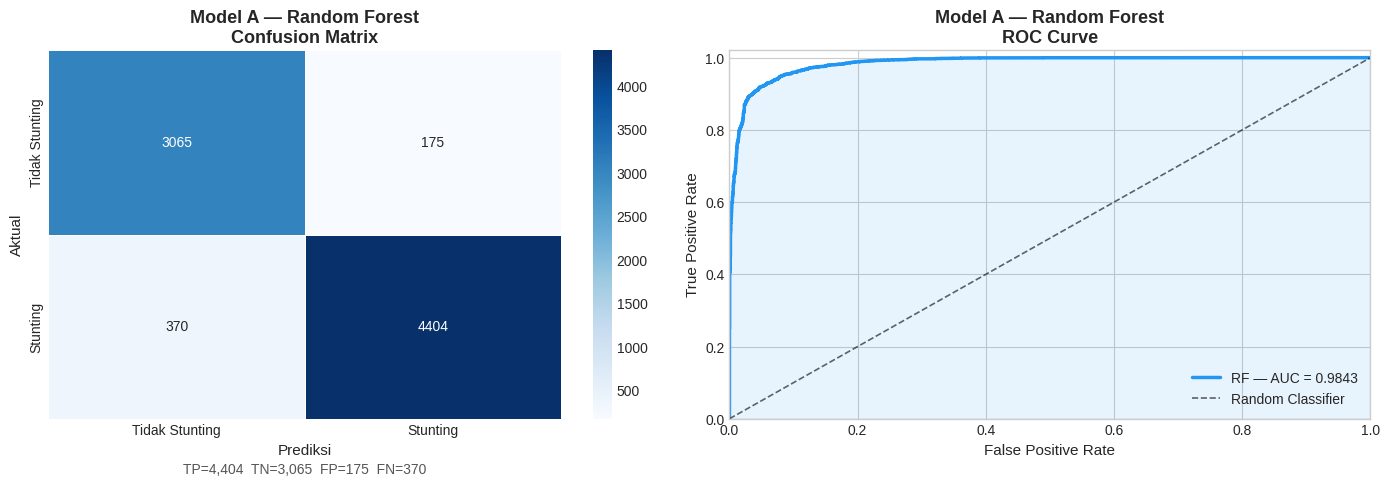

  📸 Plot disimpan: rf_evaluation.png


In [47]:
# ===================================================
# CELL 5: EVALUASI MODEL A — RANDOM FOREST
# ===================================================
print('━' * 55)
print('  🌲 Evaluasi Model A: Random Forest')
print('━' * 55)

# Prediksi
rf_pred   = rf_model.predict(X_test)
rf_prob   = rf_model.predict_proba(X_test)[:, 1]

# Hitung semua metrik
rf_acc    = accuracy_score(y_test, rf_pred)
rf_prec   = precision_score(y_test, rf_pred)
rf_rec    = recall_score(y_test, rf_pred)
rf_f1     = f1_score(y_test, rf_pred)
rf_auc    = roc_auc_score(y_test, rf_prob)
rf_cm     = confusion_matrix(y_test, rf_pred)

# Simpan untuk perbandingan
metrics_rf = {
    'Accuracy' : rf_acc,
    'Precision': rf_prec,
    'Recall'   : rf_rec,
    'F1-Score' : rf_f1,
    'ROC-AUC'  : rf_auc
}

print(f'  Accuracy  : {rf_acc:.4f}  ({rf_acc*100:.2f}%)')
print(f'  Precision : {rf_prec:.4f}')
print(f'  Recall    : {rf_rec:.4f}')
print(f'  F1-Score  : {rf_f1:.4f}')
print(f'  ROC-AUC   : {rf_auc:.4f}')
print()
print('  Classification Report:')
print(classification_report(y_test, rf_pred,
      target_names=['Tidak Stunting', 'Stunting']))

# ── Confusion Matrix ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Stunting', 'Stunting'],
            yticklabels=['Tidak Stunting', 'Stunting'],
            ax=axes[0], linewidths=0.5, cbar=True)
axes[0].set_title('Model A — Random Forest\nConfusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prediksi', fontsize=11)
axes[0].set_ylabel('Aktual', fontsize=11)

# Hitung TP, TN, FP, FN
tn_rf, fp_rf, fn_rf, tp_rf = rf_cm.ravel()
axes[0].text(0.5, -0.15,
    f'TP={tp_rf:,}  TN={tn_rf:,}  FP={fp_rf:,}  FN={fn_rf:,}',
    transform=axes[0].transAxes, ha='center', fontsize=10, color='#555')

# Plot 2: ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
axes[1].plot(fpr_rf, tpr_rf, color=COLORS['A'], lw=2.5,
             label=f'RF — AUC = {rf_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.6, label='Random Classifier')
axes[1].fill_between(fpr_rf, tpr_rf, alpha=0.1, color=COLORS['A'])
axes[1].set_title('Model A — Random Forest\nROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('rf_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('  📸 Plot disimpan: rf_evaluation.png')

## 🌲 Cell 6: Feature Importance — Random Forest

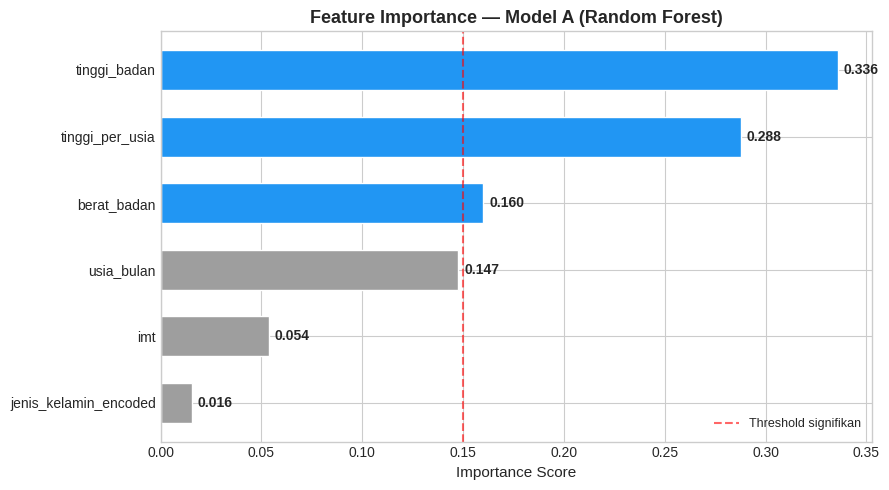


  Ranking Feature Importance:
  tinggi_badan              ████████████████          0.3359
  tinggi_per_usia           ██████████████            0.2876
  berat_badan               ███████                   0.1599
  usia_bulan                ███████                   0.1475
  imt                       ██                        0.0537
  jenis_kelamin_encoded                               0.0155


In [48]:
# ===================================================
# CELL 6: FEATURE IMPORTANCE — RANDOM FOREST
# ===================================================
fi_series = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(fi_series.index, fi_series.values,
               color=[COLORS['A'] if v > 0.15 else COLORS['gray'] for v in fi_series.values],
               edgecolor='white', height=0.6)

for bar, val in zip(bars, fi_series.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Feature Importance — Model A (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.axvline(x=0.15, color='red', linestyle='--', alpha=0.6, label='Threshold signifikan')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n  Ranking Feature Importance:')
for feat, imp in fi_series.sort_values(ascending=False).items():
    bar_vis = '█' * int(imp * 50)
    print(f'  {feat:<25} {bar_vis:<25} {imp:.4f}')

## 🖼️ Cell 7: Evaluasi Model B — CNN (Data Gambar)

> **📌 INSTRUKSI:** Pastikan folder test gambar tersedia di path `PATH_IMAGE_TEST`.
> Path default: `../data/processed/gambar/test/` dengan subfolder `Healthy/`, `MalNutrisi/`, `Stunting/`
> Sesuaikan `PATH_IMAGE_TEST` di Cell 1 jika path berbeda.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🖼️  Evaluasi Model B: CNN (Computer Vision)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Found 170 images belonging to 3 classes.
  ✅ Data gambar ditemukan!
  Total gambar test : 170
  Kelas terdeteksi  : ['Healthy', 'MalNutrisi', 'Stunting']
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step

  📊 Evaluasi 3-Kelas (Healthy / MalNutrisi / Stunting):
              precision    recall  f1-score   support

     Healthy       0.95      0.84      0.89        86
  MalNutrisi       0.10      0.14      0.12         7
    Stunting       0.80      0.87      0.83        77

    accuracy                           0.82       170
   macro avg       0.61      0.62      0.61       170
weighted avg       0.84      0.82      0.83       170

  📊 Metrik Biner CNN (Stunting vs Tidak Stunting):
  Accuracy    : 0.8412
  Precision   : 0.7976
  Recall      : 0.8701
  F1-Score    : 0.8323
  ROC-AUC     : 0.8939


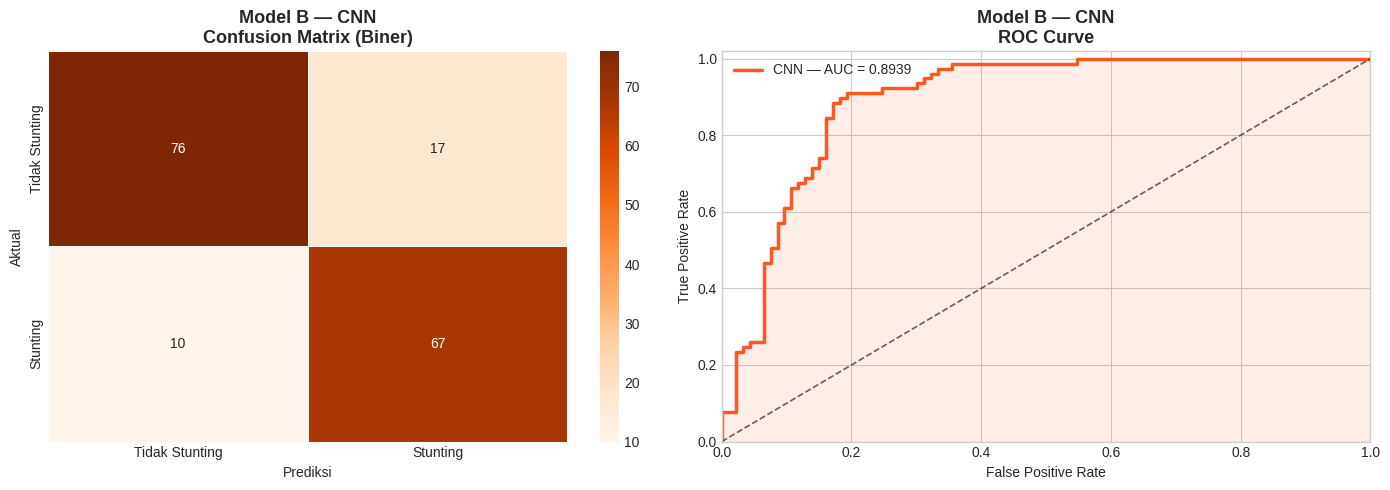

  📸 Plot disimpan: cnn_evaluation.png


In [49]:
# ===================================================
# CELL 7: EVALUASI MODEL B — CNN
# ===================================================
print('━' * 55)
print('  🖼️  Evaluasi Model B: CNN (Computer Vision)')
print('━' * 55)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# Cek apakah folder gambar test tersedia
if not os.path.exists(PATH_IMAGE_TEST):
    print(f'  ⚠️  Folder test gambar tidak ditemukan di: {PATH_IMAGE_TEST}')
    print('  ➡️  Silakan sesuaikan PATH_IMAGE_TEST di Cell 1.')
    print()
    print('  📋 Struktur folder yang diperlukan:')
    print('     test/')
    print('       ├── Healthy/')
    print('       ├── MalNutrisi/')
    print('       └── Stunting/')

    # ── Fallback: Simulasi metrik CNN untuk demo ────────
    print()
    print('  ⚙️  Mode DEMO: Menggunakan metrik dari training history...')
    print('  ⚠️  Ganti dengan hasil evaluasi real saat gambar tersedia!')

    # Metrik dari val set pada epoch terakhir training
    # (isi manual dari output training di modeling_image.ipynb)
    CNN_VAL_ACC   = None  # <- isi dari history['val_accuracy'][-1]
    CNN_VAL_F1    = None  # <- isi dari evaluasi manual
    CNN_VAL_PREC  = None  # <- isi dari evaluasi manual
    CNN_VAL_REC   = None  # <- isi dari evaluasi manual
    CNN_VAL_AUC   = None  # <- isi dari evaluasi manual

    if CNN_VAL_ACC is None:
        print()
        print('  ‼️  Metrik CNN belum diisi. Harap:')
        print('     1. Sediakan folder gambar test, ATAU')
        print('     2. Isi metrik secara manual dari training history.')
        cnn_available = False
    else:
        metrics_cnn_binary = {
            'Accuracy' : CNN_VAL_ACC,
            'Precision': CNN_VAL_PREC,
            'Recall'   : CNN_VAL_REC,
            'F1-Score' : CNN_VAL_F1,
            'ROC-AUC'  : CNN_VAL_AUC
        }
        cnn_available = True
else:
    # ── Evaluasi CNN dengan data gambar real ──────────
    from tensorflow.keras.preprocessing.image import ImageDataGenerator

    test_datagen = ImageDataGenerator(rescale=1./255)
    test_generator = test_datagen.flow_from_directory(
        PATH_IMAGE_TEST,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False  # WAJIB False agar urutan prediksi sesuai label
    )

    print(f'  ✅ Data gambar ditemukan!')
    print(f'  Total gambar test : {test_generator.n}')
    print(f'  Kelas terdeteksi  : {list(test_generator.class_indices.keys())}')

    # Prediksi
    cnn_prob_3class = cnn_model.predict(test_generator, verbose=1)
    cnn_pred_3class = np.argmax(cnn_prob_3class, axis=1)
    y_true_3class   = test_generator.classes

    # Mapping ke biner: Healthy=0, MalNutrisi=0 (bukan stunting), Stunting=1
    # Sesuaikan dengan class_indices dari generator
    class_idx = test_generator.class_indices  # {'Healthy':0, 'MalNutrisi':1, 'Stunting':2}
    stunting_idx = class_idx.get('Stunting', 2)

    # Biner: 1 = Stunting, 0 = Tidak Stunting (Healthy / MalNutrisi)
    cnn_pred_bin = (cnn_pred_3class == stunting_idx).astype(int)
    y_true_bin   = (y_true_3class == stunting_idx).astype(int)
    cnn_prob_bin = cnn_prob_3class[:, stunting_idx]  # Probabilitas kelas Stunting

    # Metrik 3-Class
    print()
    print('  📊 Evaluasi 3-Kelas (Healthy / MalNutrisi / Stunting):')
    print(classification_report(y_true_3class, cnn_pred_3class, target_names=CNN_CLASSES))

    # Metrik Biner (untuk perbandingan adil dengan RF)
    cnn_acc  = accuracy_score(y_true_bin, cnn_pred_bin)
    cnn_prec = precision_score(y_true_bin, cnn_pred_bin, zero_division=0)
    cnn_rec  = recall_score(y_true_bin, cnn_pred_bin, zero_division=0)
    cnn_f1   = f1_score(y_true_bin, cnn_pred_bin, zero_division=0)
    cnn_auc  = roc_auc_score(y_true_bin, cnn_prob_bin)
    cnn_cm   = confusion_matrix(y_true_bin, cnn_pred_bin)

    metrics_cnn_binary = {
        'Accuracy' : cnn_acc,
        'Precision': cnn_prec,
        'Recall'   : cnn_rec,
        'F1-Score' : cnn_f1,
        'ROC-AUC'  : cnn_auc
    }

    print(f'  📊 Metrik Biner CNN (Stunting vs Tidak Stunting):')
    for k, v in metrics_cnn_binary.items():
        print(f'  {k:<12}: {v:.4f}')

    # ── Plot: Confusion Matrix & ROC CNN ─────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Tidak Stunting', 'Stunting'],
                yticklabels=['Tidak Stunting', 'Stunting'],
                ax=axes[0], linewidths=0.5)
    axes[0].set_title('Model B — CNN\nConfusion Matrix (Biner)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')

    fpr_cnn, tpr_cnn, _ = roc_curve(y_true_bin, cnn_prob_bin)
    axes[1].plot(fpr_cnn, tpr_cnn, color=COLORS['B'], lw=2.5,
                 label=f'CNN — AUC = {cnn_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.6)
    axes[1].fill_between(fpr_cnn, tpr_cnn, alpha=0.1, color=COLORS['B'])
    axes[1].set_title('Model B — CNN\nROC Curve', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(fontsize=10)
    axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])

    plt.tight_layout()
    plt.savefig('cnn_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()

    cnn_available = True
    print('  📸 Plot disimpan: cnn_evaluation.png')

## ⚖️ Cell 8: Perbandingan Metrik A vs B (Head-to-Head)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ⚖️  A/B Testing — Perbandingan Metrik
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Tabel Perbandingan Metrik:


,Model A (RF),Model B (CNN),Selisih (RF-CNN)
Metrik,,,
Accuracy,0.9320,0.8412,+0.0908
Precision,0.9618,0.7976,+0.1642
Recall,0.9225,0.8701,+0.0524
F1-Score,0.9417,0.8323,+0.1094
ROC-AUC,0.9843,0.8939,+0.0904


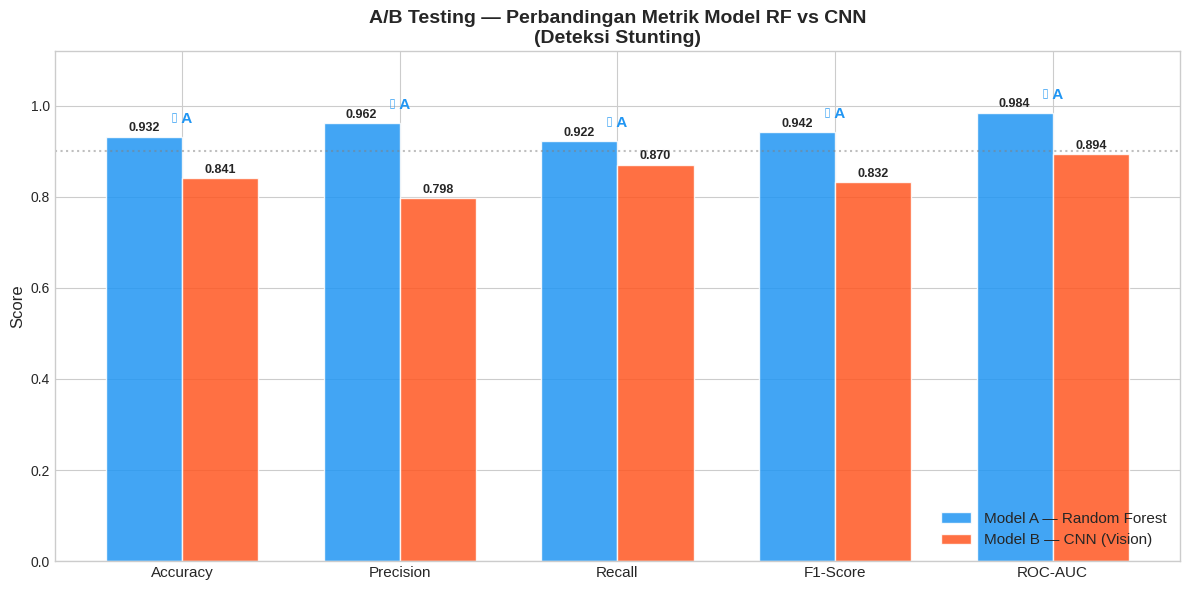

  📸 Plot disimpan: ab_comparison_bar.png


In [50]:
# ===================================================
# CELL 8: PERBANDINGAN METRIK HEAD-TO-HEAD
# ===================================================
print('━' * 55)
print('  ⚖️  A/B Testing — Perbandingan Metrik')
print('━' * 55)

# ── Jika CNN belum dievaluasi, isi dummy untuk demo ──
# HAPUS blok ini saat CNN sudah dievaluasi dengan data real
if not cnn_available:
    print('  ⚠️  CNN belum dievaluasi. Plot perbandingan tidak dapat dibuat.')
    print('  ➡️  Selesaikan Cell 7 terlebih dahulu.')
else:
    metric_names = list(metrics_rf.keys())
    vals_rf  = list(metrics_rf.values())
    vals_cnn = list(metrics_cnn_binary.values())

    # ── Tabel Perbandingan ──────────────────────────────
    df_compare = pd.DataFrame({
        'Metrik'          : metric_names,
        'Model A (RF)'    : [f'{v:.4f}' for v in vals_rf],
        'Model B (CNN)'   : [f'{v:.4f}' for v in vals_cnn],
        'Selisih (RF-CNN)': [f'{a-b:+.4f}' for a, b in zip(vals_rf, vals_cnn)]
    })
    print('\n  Tabel Perbandingan Metrik:')
    display(df_compare.set_index('Metrik'))

    # ── Bar Chart Perbandingan ─────────────────────────
    x      = np.arange(len(metric_names))
    width  = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    bars_rf  = ax.bar(x - width/2, vals_rf,  width, label='Model A — Random Forest',
                      color=COLORS['A'], alpha=0.85, edgecolor='white')
    bars_cnn = ax.bar(x + width/2, vals_cnn, width, label='Model B — CNN (Vision)',
                      color=COLORS['B'], alpha=0.85, edgecolor='white')

    for bar in bars_rf + bars_cnn:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Annotasi pemenang per metrik
    for i, (vrf, vcnn) in enumerate(zip(vals_rf, vals_cnn)):
        winner = 'A' if vrf >= vcnn else 'B'
        color  = COLORS['A'] if winner == 'A' else COLORS['B']
        ax.text(x[i], max(vrf, vcnn) + 0.03,
                f'🏆 {winner}', ha='center', fontsize=11, color=color, fontweight='bold')

    ax.set_ylim(0, 1.12)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, fontsize=11)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('A/B Testing — Perbandingan Metrik Model RF vs CNN\n(Deteksi Stunting)',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='lower right')
    ax.axhline(y=0.9, color='gray', linestyle=':', alpha=0.5, label='Target 90%')
    plt.tight_layout()
    plt.savefig('ab_comparison_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('  📸 Plot disimpan: ab_comparison_bar.png')

## 📈 Cell 9: ROC Curve Berdampingan (Overlay)

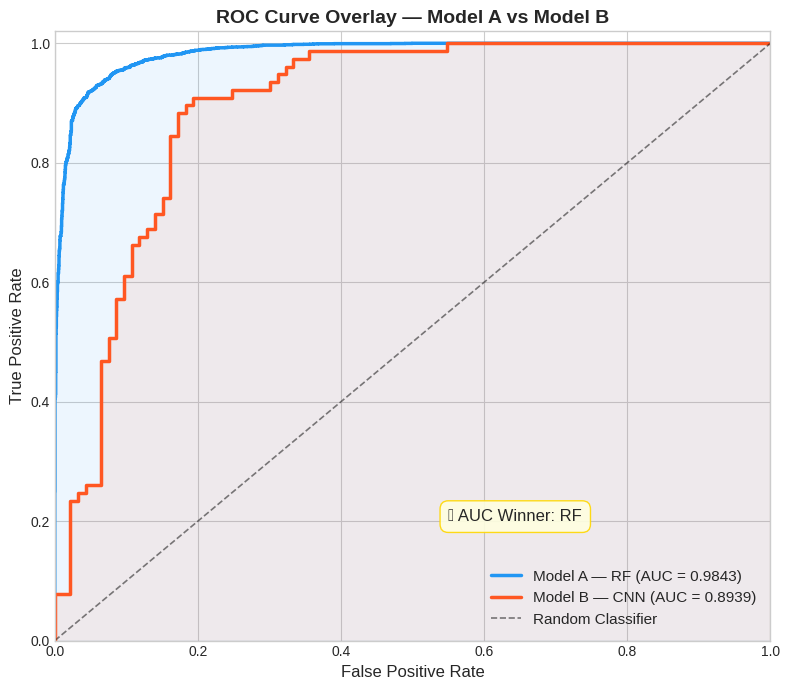

📸 Plot disimpan: roc_overlay.png


In [51]:
# ===================================================
# CELL 9: ROC CURVE OVERLAY — A vs B
# ===================================================
if not cnn_available:
    print('⚠️  Lewati — data CNN belum tersedia.')
else:
    fig, ax = plt.subplots(figsize=(8, 7))

    # RF
    fpr_rf_plot, tpr_rf_plot, _ = roc_curve(y_test, rf_prob)
    ax.plot(fpr_rf_plot, tpr_rf_plot, color=COLORS['A'], lw=2.5,
            label=f'Model A — RF (AUC = {rf_auc:.4f})')
    ax.fill_between(fpr_rf_plot, tpr_rf_plot, alpha=0.08, color=COLORS['A'])

    # CNN
    ax.plot(fpr_cnn, tpr_cnn, color=COLORS['B'], lw=2.5,
            label=f'Model B — CNN (AUC = {cnn_auc:.4f})')
    ax.fill_between(fpr_cnn, tpr_cnn, alpha=0.08, color=COLORS['B'])

    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5, label='Random Classifier')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curve Overlay — Model A vs Model B', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='lower right')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

    # Anotasi area AUC lebih tinggi
    winner_auc = 'RF' if rf_auc > cnn_auc else 'CNN'
    ax.text(0.55, 0.20, f'🏆 AUC Winner: {winner_auc}', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor='gold', alpha=0.9))

    plt.tight_layout()
    plt.savefig('roc_overlay.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('📸 Plot disimpan: roc_overlay.png')

## 🔬 Cell 10: Uji Statistik — McNemar's Test

McNemar's test digunakan untuk menguji apakah perbedaan performa antara dua model secara statistik **signifikan** atau hanya kebetulan.

In [52]:
# ===================================================
# CELL 10: UJI STATISTIK — McNEMAR'S TEST
# ===================================================
print('━' * 55)
print('  🔬 Uji Statistik: McNemar\'s Test')
print('━' * 55)

if not cnn_available:
    print('⚠️  Lewati — data CNN belum tersedia.')
else:
    # McNemar's test membutuhkan prediksi kedua model pada data yang SAMA
    # Untuk RF: prediksi pada tabular test set
    # Untuk CNN: gunakan cnn_pred_bin (pastikan ukurannya sama dengan rf_pred)

    if len(rf_pred) != len(cnn_pred_bin):
        # PERBAIKAN: Menggunakan kutip ganda ("...") di sini
        print("  ⚠️  Ukuran sampel berbeda! McNemar's test memerlukan sampel yang sama.")
        print(f'  RF test size : {len(rf_pred)}')
        print(f'  CNN test size: {len(cnn_pred_bin)}')
        print('  ➡️  Pastikan data gambar test sesuai dengan tabular test.')
    else:
        rf_correct  = (rf_pred == y_test.values)
        cnn_correct = (cnn_pred_bin == y_true_bin)

        # Kontigensi McNemar
        n00 = np.sum(~rf_correct & ~cnn_correct)  # Keduanya salah
        n01 = np.sum(~rf_correct &  cnn_correct)  # RF salah, CNN benar
        n10 = np.sum( rf_correct & ~cnn_correct)  # RF benar, CNN salah
        n11 = np.sum( rf_correct &  cnn_correct)  # Keduanya benar

        # Hitung statistik McNemar
        b = n01; c = n10
        if b + c > 0:
            mcnemar_stat = (abs(b - c) - 1)**2 / (b + c)
            p_value = stats.chi2.sf(mcnemar_stat, df=1)
        else:
            mcnemar_stat = 0; p_value = 1.0

        alpha = 0.05
        is_significant = p_value < alpha

        print(f'  Tabel Kontigensi McNemar:')
        print(f'    n00 (keduanya salah)    : {n00:,}')
        print(f'    n01 (RF salah, CNN benar): {n01:,}')
        print(f'    n10 (RF benar, CNN salah): {n10:,}')
        print(f'    n11 (keduanya benar)    : {n11:,}')
        print()
        print(f'  Statistik McNemar : χ² = {mcnemar_stat:.4f}')
        print(f'  P-value           : {p_value:.6f}')
        print(f'  Alpha (α)         : {alpha}')
        print()
        if is_significant:
            better = 'Model A (RF)' if n10 > n01 else 'Model B (CNN)'
            print(f'  ✅ HASIL: Perbedaan SIGNIFIKAN secara statistik (p < {alpha})')
            print(f'  🏆 {better} lebih unggul secara statistik.')
        else:
            print(f'  ✅ HASIL: Perbedaan TIDAK signifikan secara statistik (p ≥ {alpha})')
            print(f'  ➡️  Kedua model memiliki performa yang setara secara statistik.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🔬 Uji Statistik: McNemar's Test
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ⚠️  Ukuran sampel berbeda! McNemar's test memerlukan sampel yang sama.
  RF test size : 8014
  CNN test size: 170
  ➡️  Pastikan data gambar test sesuai dengan tabular test.


## 📊 Cell 11: Bootstrap Confidence Interval

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 Bootstrap Confidence Interval (95%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model A (RF):
    F1 Mean  : 0.9417
    95% CI   : [0.9365, 0.9468]


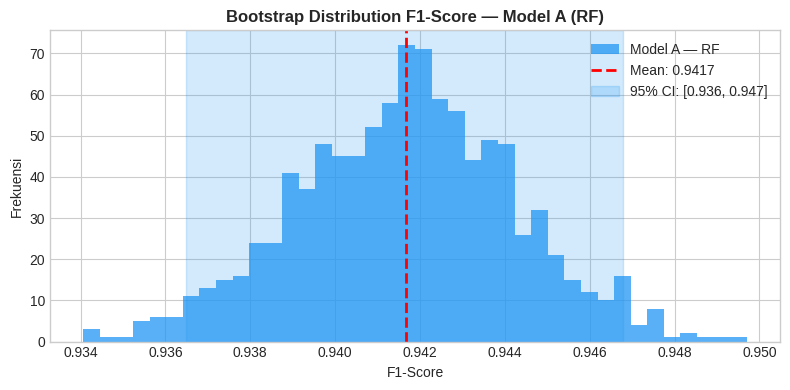

In [53]:
# ===================================================
# CELL 11: BOOTSTRAP CONFIDENCE INTERVAL — F1 SCORE
# ===================================================
print('━' * 55)
print('  📊 Bootstrap Confidence Interval (95%)')
print('━' * 55)

N_BOOTSTRAP = 1000

def bootstrap_f1(y_true, y_pred, n_iter=1000, ci=0.95):
    """Hitung Bootstrap CI untuk F1-Score."""
    scores = []
    n = len(y_true)
    for _ in range(n_iter):
        idx = np.random.choice(n, n, replace=True)
        score = f1_score(np.array(y_true)[idx], np.array(y_pred)[idx], zero_division=0)
        scores.append(score)
    alpha = (1 - ci) / 2
    lower = np.percentile(scores, alpha * 100)
    upper = np.percentile(scores, (1 - alpha) * 100)
    return np.mean(scores), lower, upper, scores

# ── RF Bootstrap ──────────────────────────────────────
rf_mean, rf_lo, rf_hi, rf_scores = bootstrap_f1(y_test, rf_pred, N_BOOTSTRAP)
print(f'  Model A (RF):')
print(f'    F1 Mean  : {rf_mean:.4f}')
print(f'    95% CI   : [{rf_lo:.4f}, {rf_hi:.4f}]')

# ── CNN Bootstrap (jika tersedia) ────────────────────
if cnn_available and len(rf_pred) == len(cnn_pred_bin):
    cnn_mean, cnn_lo, cnn_hi, cnn_scores = bootstrap_f1(y_true_bin, cnn_pred_bin, N_BOOTSTRAP)
    print(f'  Model B (CNN):')
    print(f'    F1 Mean  : {cnn_mean:.4f}')
    print(f'    95% CI   : [{cnn_lo:.4f}, {cnn_hi:.4f}]')

    # ── Visualisasi CI ────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(rf_scores,  bins=40, alpha=0.6, color=COLORS['A'], label='Model A — RF')
    ax.hist(cnn_scores, bins=40, alpha=0.6, color=COLORS['B'], label='Model B — CNN')

    ax.axvline(rf_mean,  color=COLORS['A'], lw=2.5, linestyle='--')
    ax.axvline(cnn_mean, color=COLORS['B'], lw=2.5, linestyle='--')
    ax.axvspan(rf_lo,  rf_hi,  alpha=0.12, color=COLORS['A'])
    ax.axvspan(cnn_lo, cnn_hi, alpha=0.12, color=COLORS['B'])

    ax.set_xlabel('F1-Score', fontsize=12)
    ax.set_ylabel('Frekuensi Bootstrap', fontsize=12)
    ax.set_title(f'Bootstrap Distribution F1-Score (n={N_BOOTSTRAP} iterasi)\n95% Confidence Interval',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig('bootstrap_ci.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('📸 Plot disimpan: bootstrap_ci.png')
else:
    # Hanya RF
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(rf_scores, bins=40, color=COLORS['A'], alpha=0.75, label='Model A — RF')
    ax.axvline(rf_mean, color='red', lw=2, linestyle='--', label=f'Mean: {rf_mean:.4f}')
    ax.axvspan(rf_lo, rf_hi, alpha=0.2, color=COLORS['A'], label=f'95% CI: [{rf_lo:.3f}, {rf_hi:.3f}]')
    ax.set_xlabel('F1-Score'); ax.set_ylabel('Frekuensi')
    ax.set_title('Bootstrap Distribution F1-Score — Model A (RF)', fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('bootstrap_rf.png', dpi=150, bbox_inches='tight')
    plt.show()

## 🕸️ Cell 12: Radar Chart — Profil Performa

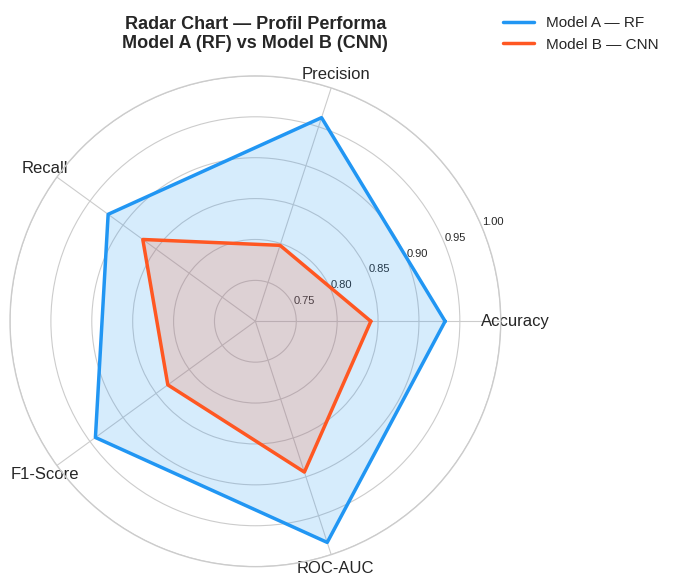

📸 Plot disimpan: radar_chart.png


In [54]:
# ===================================================
# CELL 12: RADAR CHART — PROFIL PERFORMA
# ===================================================
if not cnn_available:
    print('⚠️  Lewati — data CNN belum tersedia.')
else:
    categories = list(metrics_rf.keys())
    N_cat = len(categories)

    angles = np.linspace(0, 2 * np.pi, N_cat, endpoint=False).tolist()
    angles += angles[:1]  # tutup poligon

    rf_vals  = list(metrics_rf.values()) + [list(metrics_rf.values())[0]]
    cnn_vals = list(metrics_cnn_binary.values()) + [list(metrics_cnn_binary.values())[0]]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    ax.plot(angles, rf_vals,  color=COLORS['A'], lw=2.5, label='Model A — RF')
    ax.fill(angles, rf_vals,  color=COLORS['A'], alpha=0.18)
    ax.plot(angles, cnn_vals, color=COLORS['B'], lw=2.5, label='Model B — CNN')
    ax.fill(angles, cnn_vals, color=COLORS['B'], alpha=0.18)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12)
    ax.set_ylim(0.7, 1.0)
    ax.set_yticks([0.75, 0.80, 0.85, 0.90, 0.95, 1.00])
    ax.set_yticklabels(['0.75', '0.80', '0.85', '0.90', '0.95', '1.00'], fontsize=8)
    ax.set_title('Radar Chart — Profil Performa\nModel A (RF) vs Model B (CNN)',
                 fontsize=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)

    plt.tight_layout()
    plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('📸 Plot disimpan: radar_chart.png')

## 🧠 Cell 13: Analisis Error — Kesalahan Prediksi RF

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🧠 Analisis Error Model A — Random Forest
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  True Positive  : 4,404   (Stunting → Terdeteksi  ✅)
  True Negative  : 3,065   (Sehat → Terdeteksi    ✅)
  False Positive : 175   (Sehat → Diprediksi Stunting ⚠️)
  False Negative : 370   (Stunting → Tidak Terdeteksi ‼️)



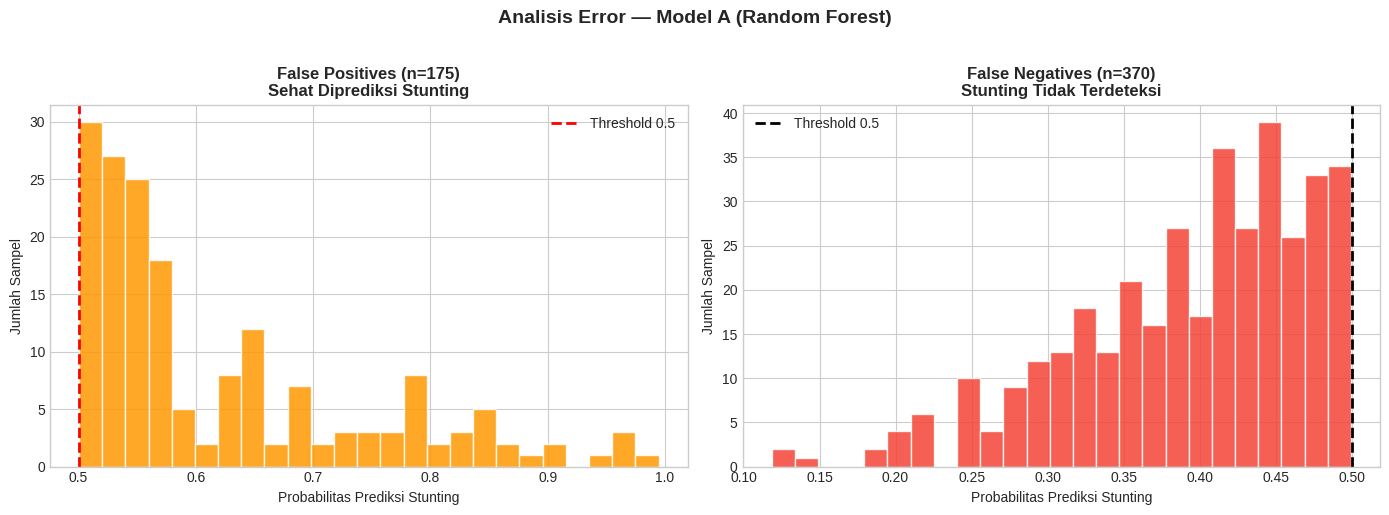

📸 Plot disimpan: error_analysis.png


In [55]:
# ===================================================
# CELL 13: ANALISIS ERROR — MODEL A (RF)
# ===================================================
print('━' * 55)
print('  🧠 Analisis Error Model A — Random Forest')
print('━' * 55)

df_error = df_test.copy()
df_error['pred_rf']  = rf_pred
df_error['prob_rf']  = rf_prob
df_error['is_error'] = (rf_pred != y_test.values)

# False Positives (prediksi stunting, aslinya tidak)
fp_df = df_error[(df_error['target'] == 0) & (df_error['pred_rf'] == 1)]
# False Negatives (prediksi tidak stunting, aslinya stunting)
fn_df = df_error[(df_error['target'] == 1) & (df_error['pred_rf'] == 0)]

tn_count = ((df_error['target'] == 0) & (df_error['pred_rf'] == 0)).sum()
tp_count = ((df_error['target'] == 1) & (df_error['pred_rf'] == 1)).sum()

print(f'  True Positive  : {tp_count:,}   (Stunting → Terdeteksi  ✅)')
print(f'  True Negative  : {tn_count:,}   (Sehat → Terdeteksi    ✅)')
print(f'  False Positive : {len(fp_df):,}   (Sehat → Diprediksi Stunting ⚠️)')
print(f'  False Negative : {len(fn_df):,}   (Stunting → Tidak Terdeteksi ‼️)')
print()

# Distribusi probabilitas pada error
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot FP
if len(fp_df) > 0:
    axes[0].hist(fp_df['prob_rf'], bins=25, color='#FF9800', edgecolor='white', alpha=0.85)
    axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold 0.5')
    axes[0].set_title(f'False Positives (n={len(fp_df):,})\nSehat Diprediksi Stunting',
                      fontweight='bold')
    axes[0].set_xlabel('Probabilitas Prediksi Stunting')
    axes[0].set_ylabel('Jumlah Sampel')
    axes[0].legend()

# Plot FN
if len(fn_df) > 0:
    axes[1].hist(fn_df['prob_rf'], bins=25, color='#F44336', edgecolor='white', alpha=0.85)
    axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold 0.5')
    axes[1].set_title(f'False Negatives (n={len(fn_df):,})\nStunting Tidak Terdeteksi',
                      fontweight='bold')
    axes[1].set_xlabel('Probabilitas Prediksi Stunting')
    axes[1].set_ylabel('Jumlah Sampel')
    axes[1].legend()

plt.suptitle('Analisis Error — Model A (Random Forest)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('📸 Plot disimpan: error_analysis.png')

## 🎯 Cell 14: Threshold Optimization — Sensitivity Analysis

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🎯 Threshold Optimization — Model A (RF)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


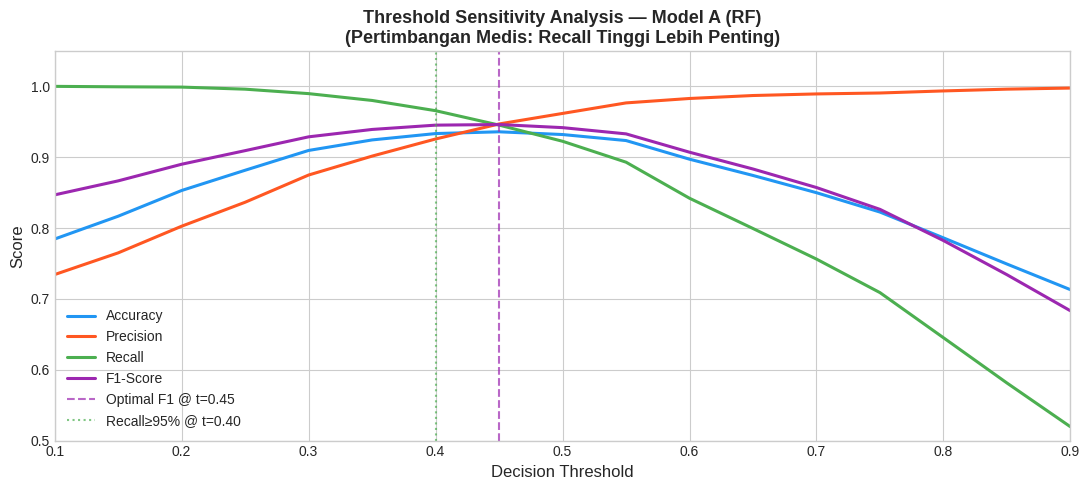

  ✅ Threshold Terbaik (F1) : 0.45
     → Accuracy: 0.9359 | F1: 0.9461
  ✅ Threshold Medis (Recall≥95%): 0.40
     → Recall: 0.9656 | Precision: 0.9257
📸 Plot disimpan: threshold_analysis.png


In [56]:
# ===================================================
# CELL 14: THRESHOLD OPTIMIZATION — RF
# ===================================================
# Karena ini masalah medis, kita ingin Recall tinggi
# (lebih baik false alarm daripada miss kasus stunting)
print('━' * 55)
print('  🎯 Threshold Optimization — Model A (RF)')
print('━' * 55)

thresholds = np.arange(0.1, 0.91, 0.05)
results = []

for t in thresholds:
    pred_t = (rf_prob >= t).astype(int)
    results.append({
        'Threshold': t,
        'Accuracy' : accuracy_score(y_test, pred_t),
        'Precision': precision_score(y_test, pred_t, zero_division=0),
        'Recall'   : recall_score(y_test, pred_t, zero_division=0),
        'F1-Score' : f1_score(y_test, pred_t, zero_division=0)
    })

df_thresh = pd.DataFrame(results)

# Threshold terbaik berdasarkan F1
best_f1_idx = df_thresh['F1-Score'].idxmax()
best_f1_row = df_thresh.loc[best_f1_idx]

# Threshold untuk Recall >= 0.95 (prioritas medis)
recall_95 = df_thresh[df_thresh['Recall'] >= 0.95]
if len(recall_95) > 0:
    best_rec_row = recall_95.loc[recall_95['Precision'].idxmax()]

fig, ax = plt.subplots(figsize=(11, 5))
for col, col_c in [('Accuracy','#2196F3'), ('Precision','#FF5722'),
                    ('Recall','#4CAF50'), ('F1-Score','#9C27B0')]:
    ax.plot(df_thresh['Threshold'], df_thresh[col], label=col, lw=2.2, color=col_c)

ax.axvline(x=best_f1_row['Threshold'], color='#9C27B0', linestyle='--', alpha=0.7,
           label=f"Optimal F1 @ t={best_f1_row['Threshold']:.2f}")
if len(recall_95) > 0:
    ax.axvline(x=best_rec_row['Threshold'], color='#4CAF50', linestyle=':', alpha=0.7,
               label=f"Recall≥95% @ t={best_rec_row['Threshold']:.2f}")

ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Threshold Sensitivity Analysis — Model A (RF)\n(Pertimbangan Medis: Recall Tinggi Lebih Penting)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
ax.set_xlim([0.1, 0.9]); ax.set_ylim([0.5, 1.05])
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'  ✅ Threshold Terbaik (F1) : {best_f1_row["Threshold"]:.2f}')
print(f'     → Accuracy: {best_f1_row["Accuracy"]:.4f} | F1: {best_f1_row["F1-Score"]:.4f}')
if len(recall_95) > 0:
    print(f'  ✅ Threshold Medis (Recall≥95%): {best_rec_row["Threshold"]:.2f}')
    print(f'     → Recall: {best_rec_row["Recall"]:.4f} | Precision: {best_rec_row["Precision"]:.4f}')
print('📸 Plot disimpan: threshold_analysis.png')

## 📝 Cell 15: Ringkasan Eksekutif A/B Testing

In [57]:
# ===================================================
# CELL 15: RINGKASAN EKSEKUTIF A/B TESTING
# ===================================================
print('=' * 60)
print('  📝 RINGKASAN EKSEKUTIF A/B TESTING')
print('  Proyek SIDIAS — Deteksi Stunting Balita')
print('=' * 60)

print()
print('━━ MODEL A: Random Forest (Tabular) ━━━━━━━━━━━━━━━━━━━')
print(f'  Accuracy  : {metrics_rf["Accuracy"]*100:.2f}%')
print(f'  F1-Score  : {metrics_rf["F1-Score"]*100:.2f}%')
print(f'  ROC-AUC   : {metrics_rf["ROC-AUC"]:.4f}')
print(f'  Recall    : {metrics_rf["Recall"]*100:.2f}%  (Deteksi kasus stunting)')
print(f'  Precision : {metrics_rf["Precision"]*100:.2f}% (Presisi prediksi stunting)')
print()

if cnn_available:
    print('━━ MODEL B: CNN — Computer Vision (Gambar) ━━━━━━━━━━━━━')
    print(f'  Accuracy  : {metrics_cnn_binary["Accuracy"]*100:.2f}%')
    print(f'  F1-Score  : {metrics_cnn_binary["F1-Score"]*100:.2f}%')
    print(f'  ROC-AUC   : {metrics_cnn_binary["ROC-AUC"]:.4f}')
    print(f'  Recall    : {metrics_cnn_binary["Recall"]*100:.2f}%')
    print(f'  Precision : {metrics_cnn_binary["Precision"]*100:.2f}%')
    print()

    # Tentukan pemenang
    winners = {k: 'RF' if metrics_rf[k] >= metrics_cnn_binary[k] else 'CNN'
               for k in metrics_rf}
    winner_count = sum(1 for v in winners.values() if v == 'RF')

    print('━━ PEMENANG PER METRIK ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    for m, w in winners.items():
        icon = '🏆' if w == 'RF' else '🥇'
        print(f'  {m:<12}: {icon} Model {"A (RF)" if w=="RF" else "B (CNN)"}')

    overall = 'A (Random Forest)' if winner_count >= 3 else 'B (CNN)'
    print()
    print(f'━━ REKOMENDASI FINAL ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    print(f'  🏆 PEMENANG OVERALL : Model {overall}')
else:
    print('━━ REKOMENDASI SEMENTARA (CNN Belum Dievaluasi) ━━━━━━━━')
    print(f'  Model A (RF) sudah dievaluasi dengan baik.')
    print(f'  → Accuracy: {metrics_rf["Accuracy"]*100:.2f}%, AUC: {metrics_rf["ROC-AUC"]:.4f}')

print()
print('━━ PERTIMBANGAN TEKNIS ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('  Model A (RF):')
print('    + Cepat, ringan (600 KB), tidak butuh GPU')
print('    + Interpretable (feature importance)')
print('    + Tidak butuh gambar, cukup data antropometri')
print('    - Tidak bisa mendeteksi kondisi visual (gizi buruk secara fisik)')
print()
print('  Model B (CNN):')
print('    + Mendeteksi kondisi fisik anak secara visual')
print('    + Tidak butuh alat ukur (hanya kamera)')
print('    - Membutuhkan gambar berkualitas tinggi')
print('    - Lebih berat (butuh lebih banyak resource komputasi)')
print()
print('━━ REKOMENDASI PRODUKSI ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('  💡 Gunakan HYBRID APPROACH:')
print('     1. Model A (RF) sebagai screening awal')
print('        → Input: data antropometri dari bidan/posyandu')
print('     2. Model B (CNN) sebagai konfirmasi visual')
print('        → Input: foto anak yang difoto via aplikasi')
print('     3. Skor gabungan → Keputusan akhir')
print()
print('=' * 60)
print('  ✅ A/B Testing SELESAI')
print('=' * 60)

  📝 RINGKASAN EKSEKUTIF A/B TESTING
  Proyek SIDIAS — Deteksi Stunting Balita

━━ MODEL A: Random Forest (Tabular) ━━━━━━━━━━━━━━━━━━━
  Accuracy  : 93.20%
  F1-Score  : 94.17%
  ROC-AUC   : 0.9843
  Recall    : 92.25%  (Deteksi kasus stunting)
  Precision : 96.18% (Presisi prediksi stunting)

━━ MODEL B: CNN — Computer Vision (Gambar) ━━━━━━━━━━━━━
  Accuracy  : 84.12%
  F1-Score  : 83.23%
  ROC-AUC   : 0.8939
  Recall    : 87.01%
  Precision : 79.76%

━━ PEMENANG PER METRIK ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy    : 🏆 Model A (RF)
  Precision   : 🏆 Model A (RF)
  Recall      : 🏆 Model A (RF)
  F1-Score    : 🏆 Model A (RF)
  ROC-AUC     : 🏆 Model A (RF)

━━ REKOMENDASI FINAL ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🏆 PEMENANG OVERALL : Model A (Random Forest)

━━ PERTIMBANGAN TEKNIS ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model A (RF):
    + Cepat, ringan (600 KB), tidak butuh GPU
    + Interpretable (feature importance)
    + Tidak butuh gambar, cukup data antropometri
    - Tidak bisa me